<a href="https://colab.research.google.com/github/Nikkuchan/colabs-notes/blob/main/Midterms/04%20-%20Regression/fund_aiml_04v1_2021.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topic 04: Regression
$_{\text{©D.J. Lopez | 2021 | Fudamentals of Machine Learning}}$

Now we are starting with the core machine learning topics. We will first try be acquainted with supervised learning specifically with statistical learning. In this notebook, we will be discussing the most fundamental algorithm in Data Science and Artificial Intelligence — Regression. Specifically we will cover the following topics:
* Linear Regression
* Least Squares
* Ridge Regression


## 4.1 Correlation
Before dwelling into regression we must first lay the difference between correlation and causation. Regression specifically talks about the causality or the the cause and effect relationship of variables. Whereas correlation talks about how associated variables are.

![img](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fd35fo82fjcw0y8.cloudfront.net%2F2018%2F07%2F05092148%2Fcorrelation-vs-causation-phone-RAM1-1024x574.png&f=1&nofb=1)

In this example we can see a distinction from correlation and causation. There will be an association with messages failing to send and the freezing of your phone. You could say something:

* A: "I can't send messages whenever my phone freezes. and conversely:

* B: "My phone froze so I can't send messages.". 

A and B still make sense even if we switch up the logic. The statements could be symmetric! But if you try to put into a condition statement or implication it doesn't give much meaning. For example we could say: 

* C: "If my phone freezes I can't send messages." and

* D: "If I can't send messages, then my phone froze".

Now the two statements does not have same meaning. This is now a perspective of causality. One factor affecting the other. Now not all variables causes the other to happen. There would be times that there is an indirect relationship, and a hidden variable establishes the causality, we call this a **confounding variable**.



### 4.1.1 Covariance

Now let's acquainted with another statistic called covariance. The covariance tells us the relationship between variables in datasets. A positive covariance indicates that the varaibles are moving along the same direction or they are directly proportional while negative covariances tell us that these variables have inverse relationships. We can compute the covariance as:

$$\text{Cov}(X,Y) = \frac{1}{N}\sum^N_{i=0}(x_i-\bar{x})(y_i-\bar{y})\\_{\text{Eq. 4.1}}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

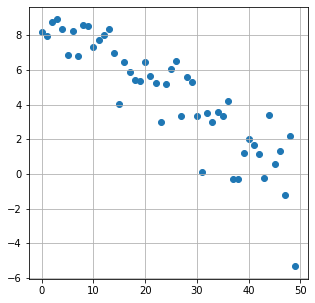

In [2]:
'''
Let's create dummy data showing positive and negative correlations
'''
def create_corr_data(n,is_neg=False):
  inv = -1 if is_neg else 1 #if inverting variable is true, then you urn it to negative else 1
  X = np.arange(0,n,1,dtype=np.float64) ## features
  m = inv*np.random.uniform(0.1,0.3,(n,)) ## weights
  b = np.random.uniform(8,10,(n,)) ## biases, b intercetp
  y = m*X+b  ## targets
  return X,y,m,b

n=50 #the more datapoints we have, the more relationship/deterministic
#when covariance is negative then there's inverse proportional relationship
#since it's showing inverse then it's negative
X,y,_,_ = create_corr_data(n,is_neg=True)

plt.figure(figsize=(5,5))
plt.grid()
plt.scatter(X,y)
plt.show()

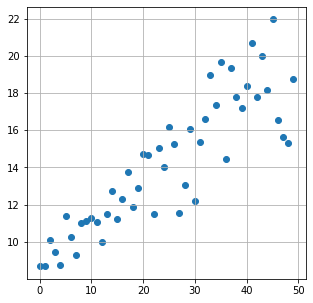

Covariance is: 44.88738621767844


In [6]:
## Coding covariances

### Prepare the dataset
n=50
X,y,_,_ = create_corr_data(n,is_neg=False)
## take the means of X and Y
x_bar = X.mean()
y_bar = y.mean()

## get the difference for each data point from their means
ssr_x = X-x_bar
ssr_y = y-y_bar

## compute for the covariance by Eq. 4.1
cov = np.mean(ssr_x*ssr_y)

plt.figure(figsize=(5,5))
plt.grid()
plt.scatter(X,y)
plt.show()
print(f'Covariance is: {cov}')

## Try to create a cov function that will dynamically ask users for two datasets

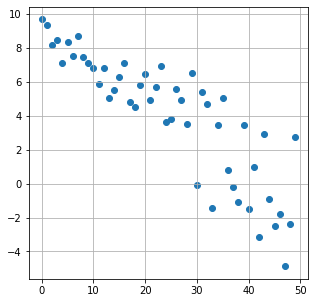

Covariance is: -45.78869175843976


In [3]:
## Coding covariances
# pearson - normalized form of the covariance.

### Prepare the dataset
n=50
X,y,_,_ = create_corr_data(n,is_neg=True) #if true then negative
## take the means of X and Y
x_bar = X.mean()
y_bar = y.mean()

## get the difference for each data point from their means
sts_x = X-x_bar #x and y are vectore
std_y = y-y_bar #use standard variation 

## compute for the covariance by Eq. 4.1
cov = np.mean(diff_x*diff_y) 

plt.figure(figsize=(5,5))
plt.grid()
plt.scatter(X,y)
plt.show()
print(f'Covariance is: {cov}')


## Try to create a cov function that will dynamically ask users for two datasets

**the greater the covariance, the more correlation
the lesser the covariance, the less correlation (inverse relationship)
 near to zero less relationship
 zero no relationship at all.**

#### Variance-Covariance Matrix

Another useful matrix in statistics is the Variance-covariance matrix. This matrix shows the dispersion of each variable. It is easier to remember the format of the matrix as:
$$\begin{bmatrix} \text{Cov}(X,X) & \text{Cov}(X,y) \\
\text{Cov}(y,X) & \text{Cov}(y,y) \end{bmatrix}$$

For brevity it can be formally expressed as:
$$\begin{bmatrix} \sigma^2_X & \text{Cov}(X,y) \\
\text{Cov}(y,X) & \sigma^2_y\end{bmatrix}$$

In [7]:
#cov x,x = cov of x 
#cov x,y = cov of y
## To get the covairance matrix we use np.cov
cov_mat = np.cov(X,y, bias=True) ## we tick the bias since we used a bias term

## We can then take cov(x,y) at the (0,1) position of a covariance matrix
cov_mat[0,1] #only x to y then splice it 
# cov_mat
#causality -- 
#if u dont find correlation between two variables, then remove all of the features
#for example in dengue cases (use temp, humibity, dolphins in paraguay) - remove paraguay

44.88738621767844

### 4.1.2 Pearson Correlation
Another measure of relationship of datasets is the Pearson Correlation Coefficient or Pearson's R. Pearson's R is specifically a measure of linear correlation between data. It can be interpreted as the ratio between the covariances of the two variables and the product of their standard deviations.
$$r_{X,y} = \frac{\text{Cov(X,y)}}{\sigma_X \sigma_y} \\_{\text{Eq. 4.2}}$$

pearson is just a covariance of x and y over the standard variance of x and y..
if covariance is zero then pearson is zero, there is no relationship.. we cant use it in determining one or another..

if covariance is negative, pearson is negative and the relation is negative


linear correlation

In [8]:
### Obtain a dataset
n=100
X,y,_,_ = create_corr_data(n,is_neg=False)

## Compute for cov(x,y)
cov_xy = np.cov(X,y, bias=True)[0,1]

## Get the st.dev of X and y
std_X = np.std(X)
std_y = np.std(y)

## Compute for Pearson's R
#pearson is always normalized (always between 0 and 1)
rho = cov_xy / (std_X*std_y)
rho

0.8731336438015761

Now you might wonder if you would use `np.corrcoeff()` it will be a different value. This is because we are using the general  form of Pearson's R for population. NumPy uses are more stable and more adaptable for samples. We will not cover it in this notebook but you if you want to know more you can read futher [here](http://statisticslectures.com/topics/pearsonr/).

$$\omega_1 = r\frac{\sigma_y}{\sigma_x}=\frac{\bar{y}*\sum(x_i^2)-\bar{x}\sum(x_i*y_i)}{\sum(x^2_i-n\bar{x}^2)}\\ _{\text{(Eq. 4.2.1)}}$$
$$\omega_0 =\bar{y}-\omega_1\bar{x}= \frac{\sum(x_i*y_i)-\bar{x}\sum(y_i)}{\sum(x^2_i-n\bar{x}^2)}\\ _{\text{(Eq. 4.2.2)}}$$

Whereas $r$ is the Pearson correlation solved as:
$$r = \frac{\sum((x-\bar{x})(y-\bar{y}))}{\sqrt{\sum(x-\bar{x})\sum(y-\bar{y})}}\\ _{\text{(Eq. 4.2.3)}}$$

In [9]:
np.corrcoef(X,y)
#they have high correlation to each other meaning they are very related 

array([[1.        , 0.87313364],
       [0.87313364, 1.        ]])

## 4.2 Linear Regression
As the name suggests, linear regression tries to find the best fit straight line to a given dataset. This algorithm is one of the simplest yet most important alogorithm in regression since it is the foundation of many more complex regression techniques.

The goal of this algorithm is finding a linear equation that would best describe a set of data. The equation to be used in finding that linear equation is function is given as:
$$y = \omega_0 + \omega_1 X \\ _{\text{Eq. 4.3}}$$

Whereas $X$ is the dataset while $y$ is the corresponding values for each datapoint in $X$. The variable $\omega$ is called the weight of the dataset consiting of $\omega_0$ and $\omega_1$. In other literature, $\omega_0$ is called the bias term sometimes written as $b$. The following equations are used to solve for $\omega_0$ and $\omega_1$:
$$\omega_1 = r\frac{\sigma_y}{\sigma_x}\\ _{\text{Eq. 4.3.1}}$$
$$\omega_0 =\bar{y}-\omega_1\bar{x}\\ _{\text{Eq. 4.3.2}}$$

**Linear reg is finding the causation between a variable x and y.**

y = mx+b

eq 4.3 is a vector..

w1 is pearson correlation
omega zero w0 = mean of y minus omega 1 multiploed to mean of x

In [10]:
## Create a dataset
n=10
X,y,m,b = create_corr_data(n,is_neg=False)
w1_th = m.mean()
w0_th = b.mean()
## Compute for the std.dev of X and y
std_X, std_y = np.std(X), np.std(y)

## Compute for Pearson's R
R = np.corrcoef(X,y)[0,1]

## Compute for the weights of the bias term
w1 = R*(std_y/std_X)

## Compute for the weights of the feature
w0 = y.mean()-w1*X.mean()

print(f"Computed w0 is {w0}, theoretical @ {w0_th}")
print(f"Computed w1 is {w1}, theoretical @ {w1_th}")
print(f"Equation: y = {w1} X + {w0}")

Computed w0 is 9.212385142345275, theoretical @ 9.041081038797945
Computed w1 is 0.15684670891940114, theoretical @ 0.1879622195546644
Equation: y = 0.15684670891940114 X + 9.212385142345275


In [11]:
## regressor y = w1*X + w0 ##model/regressor tells the relationship between data
def regressor(X,w1,w0):
  return w1*X + w0
regressor(11,w1,w0)

10.937698940458688

In [ ]:
test_X = np.arrange(10,20)
test_X

In [ ]:
predict(test_X)

In [ ]:
plt.figure(figsize=(5,5))
plt.grid()
plt.scatter(test_X,predict(test_x,w1,w0))
plt.lege
#line of best fit - this is the best representation of the dataset 

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
model = LinearRegression()
model.fit(X.reshape(-1,1),y.reshape(-1,1)) #column form #fit is training it
print(f"Weight of the feature is {model.coef_[0]}")
print(f"Bias of the model is {model.intercept_}")
print(f"Equation: y = {model.coef_[0]} X + {model.intercept_}")

Weight of the feature is [0.15684671]
Bias of the model is [9.21238514]
Equation: y = [0.15684671] X + [9.21238514]


### Metrics
Like any machine learning models we must determine their level of acceptance through measurements. The succeeding sections will cover on how to determine the error and accuracy of regression models

#### **Measures of Error**
Error or losses are computed to determine the robustness of a model to certain dataset. There are several ways to compute the error some of them are:
* Sum of Squares Total
* Sum of Squares Regression
* Sum of Squares Error
* Mean Squared Error
* Mean Absolute Error
* Mean Abosulute Percentage Error

##### *Sum of Squares Total*
The Sum of Squares Total or SST is a measure of the variability of dataset it is computed by:
$$SST = \sum_{i=0}^n(y_i-\bar{y})^2 \\_\text{Eq.4.3.3}$$

In [ ]:
def SST(y):
  return np.sum(np.square(y-y.mean()))
  #variability with respect to its mean

##### *Sum of Squares Regression*
The Sum of Squares Regression or SSR is a measure of the variability of the model it is computed by:
$$SSR = \sum_{i=0}^n(\hat{y_i}-\bar{y})^2 \\_\text{Eq.4.3.4}$$

In [ ]:
def SSR(hypothesis, y)L
  return np.sum(np.square(hypothesis,y.mean()))

##### *Sum of Squares Regression*
The Sum of Squares Regression or SSE is a measure of the variability of the model with respect to the residuals or its deviation from the ground truths, it is computed by:
$$SSR = \sum_{i=0}^n(\hat{y_i}-y_i)^2 \\_\text{Eq.4.3.5}$$

In [ ]:
#taking the actual from the predicted
def SSE(hypothesis,y):
  return np.sum(np.square(hypothesis-y)) 

##### *Mean of Squared Error*
The Mean Squared Error or MSE the name suggests it is the mean of the squared errors or SSE. It is the average error of a model. It is computed as:
$$MSE = \frac{1}{n}\sum_{i=0}^n(\hat{y_i}-y_i)^2 \\_\text{Eq.4.3.6}$$

In [ ]:
def MSE(hypothesis,y):
  return np.mean(np.square(hypothesis-y)) 

##### *Mean of Absolute Error*
The Mean Absolute Error or MAE, is another error measurement between the model and the ground truths but uses the Manhattan distance instead of the Euclidean distance from SSE.
$$MAE = \frac{1}{n}\sum_{i=0}^n|\hat{y_i}-y_i| \\_\text{Eq.4.3.7}$$

In [ ]:
def MAE(hypothesis,y):
  return np.mean(np.abs(hypothesis-y)) 

##### *Mean of Absolute Percentage Error*
The Mean Absolute Percentage Error or MAPE, is another error measurement derived from MAE but this time the error normalized. It is computed as:
$$MAE = \frac{100\%}{n}\sum_{i=0}^n|\frac{\hat{y_i}-y_i}{y_i}| \\_\text{Eq.4.3.8}$$

In [ ]:
def MAPE(hypothesis,y):
  return 100*np.mean(np.abs(hypothesis-y)/y)) 

##### *Root Mean Squared Error*
The Root Mean Squared Error or RMSE, is the root of the RMSE which brings it back to its actual unit. It is computed as:
$$RMSE = \sqrt{\frac{1}{n}\sum_{i=0}^n(\hat{y_i}-y_i)^2} \\_\text{Eq.4.3.9}$$

In [ ]:
def MSE(hypothesis,y):
  return np.mean(np.square(hypothesis-y)) 
  #WE NEED TO MINIMIZE THE ERROR SO WE'RE CLOSE TO REALITY
  #THE GREATER THE ERROR, THE WORSE THE CHU CHU IS

#### Measures Accuracy
We measure the accuracy of the regression through its explainability. We measure it through the R-squared or the Adjusted R-squared.

#### *R-squared*
The R-squared is a statistical measurement also known as the coefficient of determination wherein it shows the explanatory power of the variables used in the model. It is computed by:

$$R^2 = 1 - \frac{SSE}{SST}\\_\text{Eq.4.3.10}$$


#### *Adjusted R-squared*
The Adjusted R-squared is another statistical measurement for detemrinign the explanatory power of a model. Unlike, R-squared it is adjusted accordingly to the total datapoints and the features involved in the computation. It is computed by:

$$Adj. R^2 = 1 - \frac{SSE}{SST}\cdot \frac{n-1}{n-k-1} = 1 - \frac{(1-R^2)(n-1)}{n-k-1}\\_\text{Eq.4.3.10}$$

Whereas $n$ is the total number of datapoints in the dataset and $k$ is the total number of features to be used in the regression.

## 4.3 Least Squares
The least squares method is an optimization alogrithm in finding the best fit line for a given dataset. Just like with any numerical technique it utilizes iterations to mimimize the error.


### 4.3.1 Iteration Method
The main idea of the iteration method is to iteratively fit a line to the dataset. We tend to guess iteratively whether the line we are fitting is right. With this we can call the line the we are going to fit as the hypothesis or $h_\theta$ we can then compute the $h_\theta$ for this linear regression problem as:
$$h_\theta = \theta X+b \\_\text{Eq.4.4.1}$$
Whereas $X$ is the feature vector, $b$ is the bias vector, and $\theta$ is the weight vector  of the features. We then determine whether our hypothesis is correct by determining its error. Its error is determined by the Sum of Squared Error or SSE. We compute the SSE as the sum of the distances of each hypothesis $h_\theta$ to the target $y$. We denote the SSE as the loss function of this optimization problem, we denote it as $J(\theta)$.
$$J(\theta) =  \sum(h_\theta - y)^2\\_\text{Eq.4.4.2}$$
We then delare the optimization goal for this problem as to minimize the loss function:
$$\min(J)\\_\text{Eq.4.4.3}$$

In [ ]:
## Create a Dataset
n=30
X,y,_,_ = create_corr_data(n,is_neg=False)

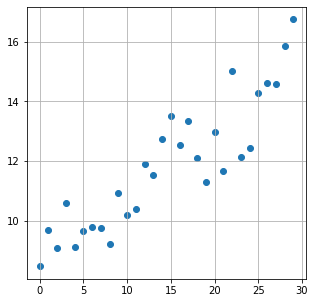

In [ ]:
plt.figure(figsize=(5,5))
plt.grid()
plt.scatter(X,y)

In [ ]:
## Modelling optimization routine using first iteration
## initialize optimization variables
def init_linear_reg(X,y):
  theta = 0 ##angle is 0
  b = 0
  h = theta*X + b
  return theta,b, h
theta, b, h = init_linear_reg(X,y)

In [ ]:
def SSR(h,y):
  return np.sum(np.square(h-y))
  J = SSR(h,y)
J

7688.857114763188

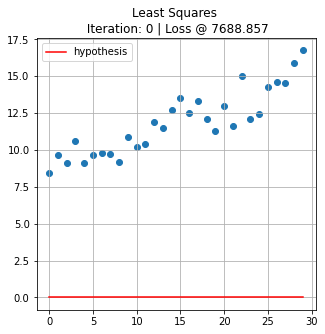

In [ ]:
def disp_hypothesis(X,y,h,loss,iter):
  plt.figure(figsize=(5,5))
  plt.title(f"Least Squares \n Iteration: {iter} | Loss @ {round(loss,3)}")
  plt.grid()
  plt.scatter(X,y)
  plt.plot(h, color='red', label='hypothesis')
  plt.legend()
  plt.show()
disp_hypothesis(X,y,h,J,0)

In [ ]:
## Design the optimization iterations
### set the range and steps
min, max = -100, 100
steps = 1
iters = np.arange(min,max+steps,steps)

### do a sanity check for the loop
# for iter in iters:
#   print(iter)

In [ ]:
## initialize the optimization routing
print("[INFO] Initializing Linear Regression parameters...")
theta, b, h = init_linear_reg(X,y)
print("[INFO] Initialization done!")

## create logs for optimization backtracking
opts = {
    'epoch': [],
    'theta': [],
    'model': [],
    'loss': []
}
print("[INFO] Starting optimzation...")
for iter in iters:
  ## set the angle as the normalized ratio of the iter to max
  theta = iter/max
  ## compute for the hypothesis
  h = theta*X + b
  ## compute for the loss
  J = SSR(h,y)

  ## log the changes
  opts['epoch'].append(iter)
  opts['theta'].append(theta)
  opts['model'].append(h)
  opts['loss'].append(J)
  print(f"[INFO] Epoch {iter} | Loss: {J}")

In [ ]:
opts_df = pd.DataFrame(opts)
opts_df

,epoch,theta,model,loss
0,-100,-1.00,"[0.0, -1.0, -2.0, -3.0, -4.0, -5.0, -6.0, -7.0...",24251.186808
1,-99,-0.99,"[0.0, -0.99, -1.98, -2.9699999999999998, -3.96...",23967.631537
2,-98,-0.98,"[0.0, -0.98, -1.96, -2.94, -3.92, -4.9, -5.88,...",23685.787267
3,-97,-0.97,"[0.0, -0.97, -1.94, -2.91, -3.88, -4.85, -5.82...",23405.653996
4,-96,-0.96,"[0.0, -0.96, -1.92, -2.88, -3.84, -4.8, -5.76,...",23127.231725
...,...,...,...,...
196,96,0.96,"[0.0, 0.96, 1.92, 2.88, 3.84, 4.8, 5.76, 6.72,...",1371.563770
197,97,0.97,"[0.0, 0.97, 1.94, 2.91, 3.88, 4.85, 5.82, 6.79...",1423.364500
198,98,0.98,"[0.0, 0.98, 1.96, 2.94, 3.92, 4.9, 5.88, 6.859...",1476.876229
199,99,0.99,"[0.0, 0.99, 1.98, 2.9699999999999998, 3.96, 4....",1532.098959


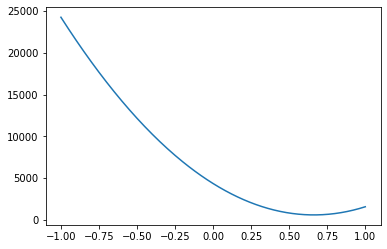

In [ ]:
plt.plot(opts['theta'], opts['loss'])

In [ ]:
### gets the index of the least error
opts_df['loss'].idxmin()
### retrieve the theta of the least error
opt_vals = opts_df.iloc[opts_df['loss'].idxmin()]

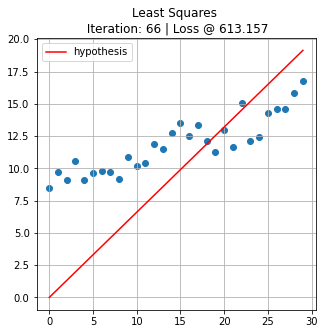

In [ ]:
## Plotting
model = theta_opt*X +b
disp_hypothesis(X,y,opt_vals['model'], opt_vals['loss'], opt_vals['epoch'])

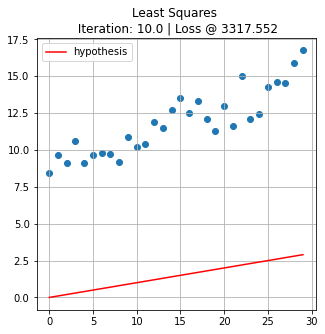

In [ ]:
epoch = 10
vals = opts_df.loc[opts_df['epoch']==epoch]
disp_hypothesis(X,y,vals['model'].iloc[0],
                float(vals['loss']), 
                float(vals['epoch']))